# <font color='blue'>Data Science Academy - Machine Learning</font>

# <font color='blue'>Análise de Segmentação de Clientes de Varejo Online RFM + IA com SAP Business Data Cloud</font>


# <font color='blue'>Fabio Ferri - 28/04/2026</font>



### RFM Varejo Online

https://www.kaggle.com/code/hellbuoy/online-retail-k-means-hierarchical-clustering/notebook

In [ ]:
# importar bibliotecas necessárias para dataframe e visualização

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# importar bibliotecas necessárias para clusterização
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

## Problema/Entendimento do Negócio:

Identifique e classifique a segmentação de clientes com o objetivo de criar campanhas de marketing direcionadas para clientes e produtos.

**Definição de Segmentação de Clientes:**

Segmentação de clientes é o processo de dividir a base de clientes em grupos homogêneos com base em características comuns, como comportamento de compra, demografia, localização ou psicografia. O objetivo é permitir que as empresas personalizem suas estratégias de marketing, melhorem a satisfação do cliente e aumentem a eficiência de campanhas promocionais.

**Definição de RFM:**

RFM (Recência, Frequência e Valor Monetário) é uma técnica de análise de clientes que avalia três dimensões principais para medir o valor e o comportamento do cliente:

- **Recência (R):** Tempo decorrido desde a última compra do cliente, indicando quão recente foi seu engajamento.
- **Frequência (F):** Número de compras efetuadas pelo cliente em um período determinado, refletindo lealdade e hábito de consumo.
- **Valor Monetário (M):** Valor total gasto pelo cliente, representando sua contribuição financeira para a empresa.

Essa análise ajuda a identificar os clientes mais valiosos, segmentá-los e direcionar campanhas de marketing personalizadas, otimizando recursos e maximizando o retorno sobre o investimento.

Você deve executar as seguintes tarefas:
    
1- Tratar valores ausentes nos dados.

2- Coletar uma amostra de 1% dos dados para criar o modelo de clusterização K-Means.

3- Encontrar o melhor valor de K para esse conjunto de dados.

4- Criar o modelo K-Means usando o valor de K encontrado no passo 3.

5- Criar uma malha (meshgrid) para visualização de todos os clusters.

6- Visualizar os centróides.

## Aquisição de Dados

Identifique e obtenha conjuntos de dados relevantes para o problema em questão.
Colete dados de múltiplas fontes, como bancos de dados, APIs, arquivos locais, etc.

In [ ]:
# Lendo os dados para análise

df_retail = pd.read_csv("dados/OnlineRetail.csv", sep=";", encoding="UTF-8", header=0)


## Limpeza e Pré-processamento de Dados:

Avalie a qualidade dos dados e trate questões como valores ausentes, outliers e erros.
Normalize ou padronize os dados quando necessário.

In [ ]:
# Exibir primeiras linhas
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,"2,55",17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,"2,75",17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,"3,39",17850.0,United Kingdom


In [ ]:
# Dimensão do DataFrame
df_retail.shape

(541909, 8)

In [ ]:
# Descrição do DataFrame
df_retail.describe()

,Quantity,CustomerID
count,541909.000000,406829.000000
mean,9.552250,15287.690570
std,218.081158,1713.600303
min,-80995.000000,12346.000000
25%,1.000000,13953.000000
50%,3.000000,15152.000000
75%,10.000000,16791.000000
max,80995.000000,18287.000000


In [ ]:
# Informações do DataFrame
df_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [ ]:
# Dimensão
df_retail.shape

(541909, 8)

In [ ]:
# Verificar valores ausentes
df_retail.isnull().values.any()

np.True_

In [ ]:
# Remover registros com valores ausentes
df_retail = df_retail.dropna()

In [ ]:
# Verificar valores ausentes
print(df_retail.isna().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
# Verificar valores únicos
df_retail.nunique()

InvoiceNo      22190
StockCode       3684
Description     3896
Quantity         436
InvoiceDate    20460
UnitPrice        620
CustomerID      4372
Country           37
dtype: int64

## Engenharia de Recursos

Realize a engenharia de recursos para criar novas características relevantes.

Vamos analisar os clientes com base nos 3 fatores abaixo:
R (Recência): Número de dias desde a última compra
F (Frequência): Número de transações
M (Monetário): Valor total das transações (receita contribuída)

In [ ]:
# Novo Atributo: Monetário


# Isso remove pontos (milhares) e substitui a vírgula (decimal) por ponto
from ast import If

# Filtra InvoiceNo para manter apenas linhas onde contém apenas dígitos (inteiros)
df_retail = df_retail[df_retail["InvoiceNo"].str.isdigit()]

df_retail["UnitPrice"] = pd.to_numeric(
    df_retail["UnitPrice"].str.replace('.', '').str.replace(',', '.'), 
    errors='coerce'
)

df_retail["UnitPrice"] = df_retail["UnitPrice"].astype(float)


if ((df_retail["Quantity"] != 0 ) & (df_retail["UnitPrice"] != 0)).any():
    df_retail["Amount"] = (df_retail["Quantity"] * df_retail["UnitPrice"])


df_retail["Amount"] = df_retail["Amount"].astype(float)

# Soma por CustomerID
rfm_m = df_retail.groupby(['CustomerID'])['Amount'].sum().reset_index()
#rfm_m = rfm_m.reset_index()
rfm_m.head()


,CustomerID,Amount
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


In [13]:
# Check for missing values
print(df_retail.isna().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Amount         0
dtype: int64


In [14]:
df_retail.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom,20.34


In [ ]:
# Novo Atributo: Frequência

rfm_f = df_retail.groupby('CustomerID')['InvoiceNo'].count()
rfm_f = rfm_f.reset_index()
rfm_f.columns = ['CustomerID', 'Frequency']
rfm_f.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,182
2,12348.0,31
3,12349.0,73
4,12350.0,17


In [ ]:
# Mesclar os dois dataframes

rfm = pd.merge(rfm_m, rfm_f, on='CustomerID', how='inner')
rfm.head()

,CustomerID,Amount,Frequency
0,12346.0,77183.60,1
1,12347.0,4310.00,182
2,12348.0,1797.24,31
3,12349.0,1757.55,73
4,12350.0,334.40,17


In [ ]:
# Novo Atributo: Recência

# Converter para datetime para o tipo de dado correto

df_retail['InvoiceDate'] = pd.to_datetime(df_retail['InvoiceDate'],format='%d/%m/%Y %H:%M')

In [ ]:
# Calcular a data máxima para saber a última transação

max_date = max(df_retail['InvoiceDate'])
max_date

Timestamp('2011-12-09 12:50:00')

In [ ]:
# Calcular a diferença entre a data máxima e a data da transação

df_retail['Diff'] = max_date - df_retail['InvoiceDate']
df_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount,Diff
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373 days 04:24:00
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373 days 04:24:00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373 days 04:24:00


In [ ]:
# Calcular a última data de transação para obter a recência dos clientes

rfm_p = df_retail.groupby('CustomerID')['Diff'].min()
rfm_p = rfm_p.reset_index()
rfm_p.head()

,CustomerID,Diff
0,12346.0,325 days 02:49:00
1,12347.0,1 days 20:58:00
2,12348.0,74 days 23:37:00
3,12349.0,18 days 02:59:00
4,12350.0,309 days 20:49:00


In [ ]:
# Extrair apenas os dias

rfm_p['Diff'] = rfm_p['Diff'].dt.days
rfm_p.head()

,CustomerID,Diff
0,12346.0,325
1,12347.0,1
2,12348.0,74
3,12349.0,18
4,12350.0,309


In [ ]:
# Mesclar dataframes para obter o dataframe final RFM

rfm = pd.merge(rfm, rfm_p, on='CustomerID', how='inner')
rfm.columns = ['CustomerID', 'Amount', 'Frequency', 'Recency']
rfm.head()

,CustomerID,Amount,Frequency,Recency
0,12346.0,77183.60,1,325
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309


## Pré-processamento de Dados

Text(0.5, 0, 'Attributes')

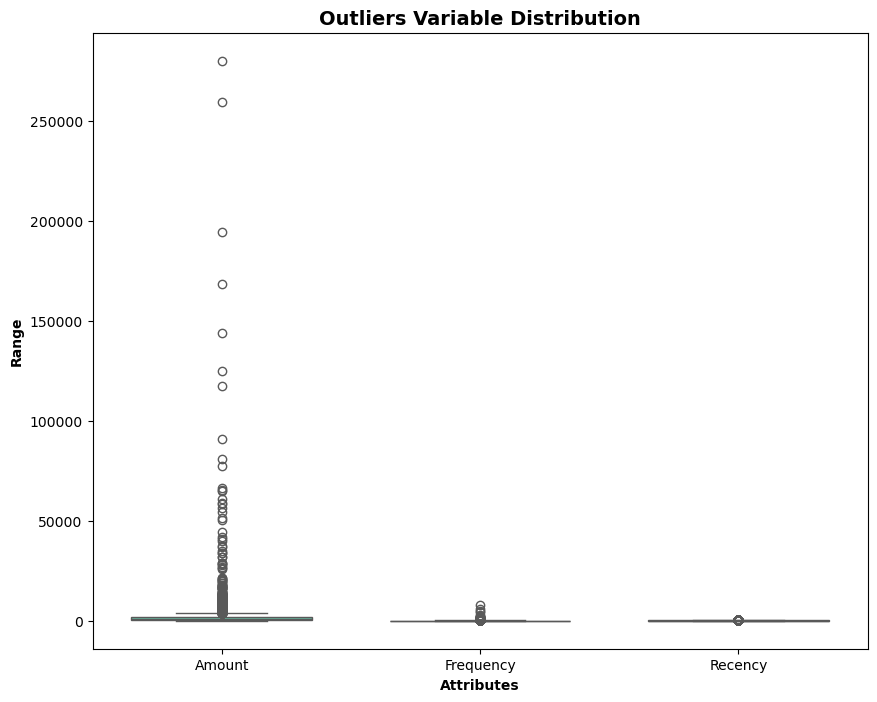

In [ ]:
# Análise de outliers para Amount, Frequency e Recency

attributes = ['Amount','Frequency','Recency']
plt.rcParams['figure.figsize'] = [10,8]
sns.boxplot(data = rfm[attributes], orient="v", palette="Set2" ,whis=1.5,saturation=1, width=0.7)
plt.title("Distribuição de Outliers", fontsize = 14, fontweight = 'bold')
plt.ylabel("Intervalo", fontweight = 'bold')
plt.xlabel("Atributos", fontweight = 'bold')

In [ ]:
# Remover outliers estatísticos para Amount
Q1 = rfm.Amount.quantile(0.05)
Q3 = rfm.Amount.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Amount >= Q1 - 1.5*IQR) & (rfm.Amount <= Q3 + 1.5*IQR)]

# Remover outliers estatísticos para Recency
Q1 = rfm.Recency.quantile(0.05)
Q3 = rfm.Recency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Recency >= Q1 - 1.5*IQR) & (rfm.Recency <= Q3 + 1.5*IQR)]

# Remover outliers estatísticos para Frequency
Q1 = rfm.Frequency.quantile(0.05)
Q3 = rfm.Frequency.quantile(0.95)
IQR = Q3 - Q1
rfm = rfm[(rfm.Frequency >= Q1 - 1.5*IQR) & (rfm.Frequency <= Q3 + 1.5*IQR)]

Reescalando os Atributos
É extremamente importante reescalar as variáveis para que tenham uma escala comparável. Existem duas maneiras comuns de reescalamento:

Escalonamento Min-Max
Padronização (média 0, desvio padrão 1)
Aqui, usaremos a padronização.

In [25]:
rfm[['CustomerID', 'Amount', 'Frequency', 'Recency']]

,CustomerID,Amount,Frequency,Recency
1,12347.0,4310.00,182,1
2,12348.0,1797.24,31,74
3,12349.0,1757.55,73,18
4,12350.0,334.40,17,309
5,12352.0,2506.04,85,35
...,...,...,...,...
4333,18278.0,173.90,9,73
4334,18280.0,180.60,10,277
4335,18281.0,80.82,7,180
4336,18282.0,178.05,12,7


In [26]:
# Rescale the attributes

rfm_df = rfm[['CustomerID','Amount', 'Frequency', 'Recency']]
rfm_df.info()

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform
rfm_df_scaled = scaler.fit_transform(rfm_df)
rfm_df_scaled.shape

<class 'pandas.core.frame.DataFrame'>
Index: 4257 entries, 1 to 4338
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CustomerID  4257 non-null   float64
 1   Amount      4257 non-null   float64
 2   Frequency   4257 non-null   int64  
 3   Recency     4257 non-null   int64  
dtypes: float64(2), int64(2)
memory usage: 166.3 KB


(4257, 4)

In [27]:
rfm_df_scaled = pd.DataFrame(rfm_df_scaled)
rfm_df_scaled.columns = ['CustomerID','Amount', 'Frequency', 'Recency']
rfm_df_scaled.head()

,CustomerID,Amount,Frequency,Recency
0,-1.715990,1.645726,1.067832,-0.917872
1,-1.715409,0.262124,-0.460601,-0.189272
2,-1.714828,0.240269,-0.035474,-0.748198
3,-1.714248,-0.543361,-0.602310,2.156221
4,-1.713086,0.652411,0.085991,-0.578524


## Análise Exploratória de Dados

Exploração de Dados:
Realize análises exploratórias para entender a distribuição dos dados, identificar padrões e relações.
Visualize os dados usando gráficos e estatísticas descritivas.

## Modelagem de Dados:

Selecione os algoritmos de machine learning ou técnicas de análise de dados mais apropriados para o problema.
Divida os dados em conjuntos de treino, validação e teste.
Treine e ajuste os modelos usando os dados de treino.

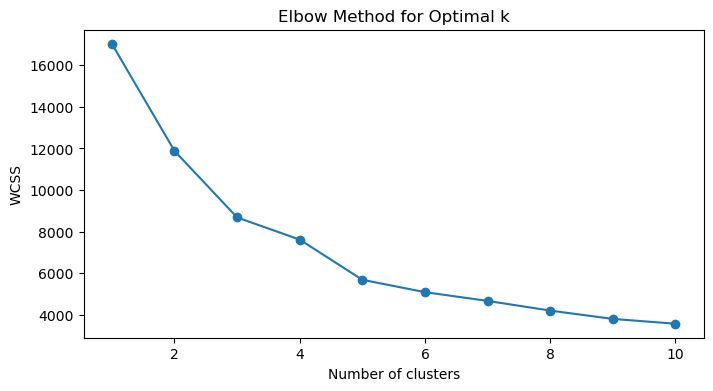

In [ ]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método Elbow para k ideal')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()


Resumo da Análise:
O gráfico relaciona o número de clusters (eixo X) com a Inércia (eixo Y). A inércia mede a distância dos pontos até o centro do cluster (quanto menor, melhor).
O "cotovelo": À medida que $k$ aumenta, a inércia diminui. O ponto ideal é a "curva" no gráfico onde a queda acentuada passa a ser gradual.
Melhor Classificação: Esse é o valor de $k$ nesse ponto de inflexão. Ele representa o melhor equilíbrio entre compactação (dados bem agrupados) e simplicidade (poucos grupos).

<a id="3.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Model 1 - Applying K-Means Clustering</b></div>

In [29]:
# Train K-Means model with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_df_scaled)

 
## Analysis Summary - K-Means Model with 5 Clusters

After applying the K-Means algorithm with k=5, we obtained customer segmentation into 5 distinct groups. The distribution of customers by cluster is as follows:

- **Cluster 0:** Customers with low activity and reduced monetary value
- **Cluster 1:** Moderate customers with medium purchase frequency
- **Cluster 2:** Occasional customers with high recency
- **Cluster 3:** Highly active and valuable customers
- **Cluster 4:** Frequent customers with good value potential


<a id="4.1"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b>Modelo 1 - Visualização Pairplot</b></div>



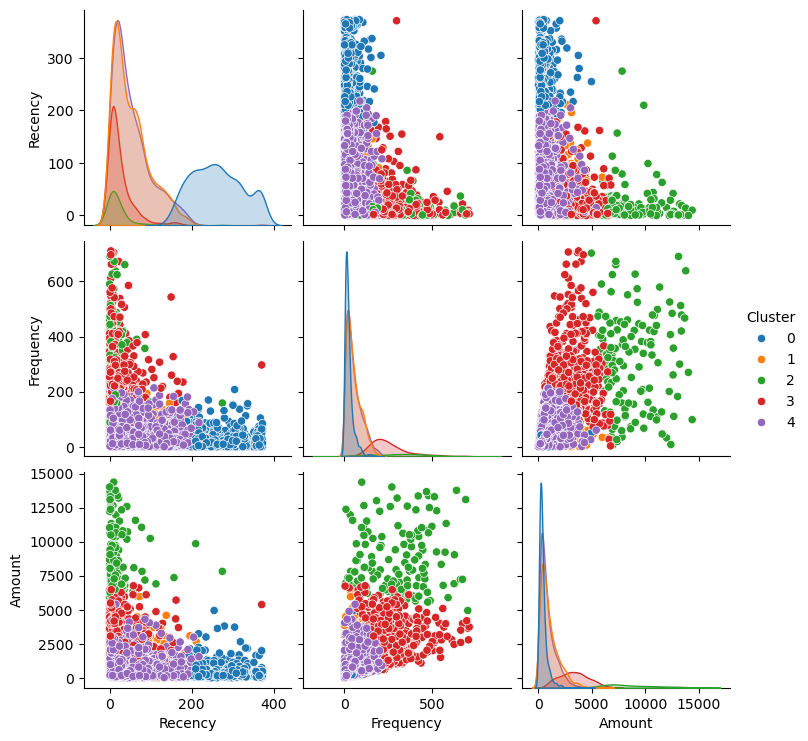

In [30]:
sns.pairplot(rfm, hue='Cluster', vars=['Recency', 'Frequency', 'Amount'], palette='tab10')
plt.show()


<a id="4.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b>Modelo 1 - Visualização de Clusters (Scatterplot)</b></div>

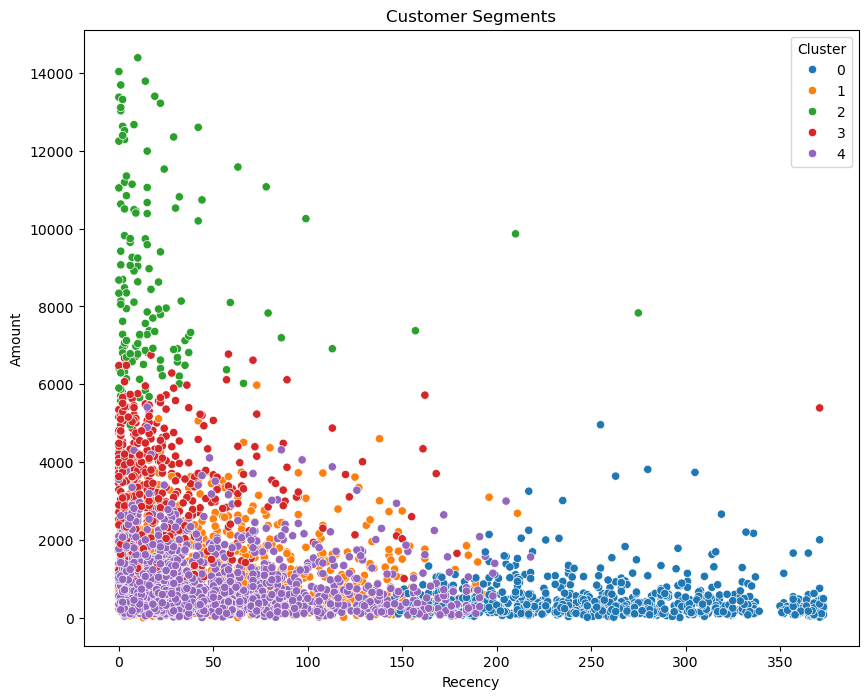

In [ ]:
sns.scatterplot(data=rfm, x='Recency', y='Amount', hue='Cluster', palette='tab10')
plt.title('Segmentos de Clientes')
plt.show()


<a id="4.3"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b>Modelo 1 - Segmentos de Clientes por PCA</b></div>

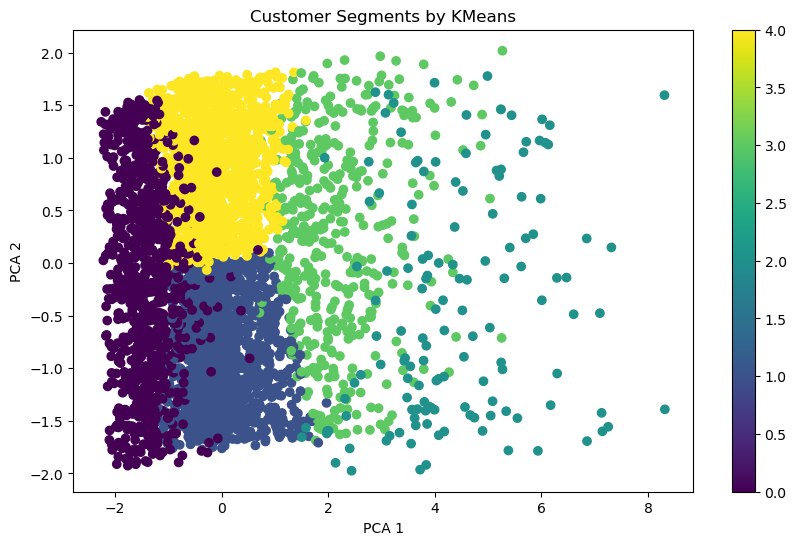

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
components = pca.fit_transform(rfm_df_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(components[:, 0], components[:, 1], c=rfm['Cluster'], cmap='viridis')
plt.title('Segmentos de Clientes por KMeans')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar()
plt.show()

<a id="3.2"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Model 2 - Applying DBSCAN Clustering</b></div>

In [33]:
# Initialize DBSCAN model (first version with default parameters)
dbscan_v1 = DBSCAN()

In [34]:
# Fit the DBSCAN model
dbscan_v1.fit(rfm_df_scaled)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [35]:
# Display cluster labels
dbscan_v1.labels_

array([0, 0, 0, ..., 0, 0, 0], shape=(4257,))

In [36]:
print(set(dbscan_v1.labels_))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(-1)}


In [37]:
# Reduce dimensionality using PCA
pca = PCA(n_components = 2).fit(rfm_df_scaled)

In [38]:
# Transform data to 2D using PCA
pca_2d = pca.transform(rfm_df_scaled)

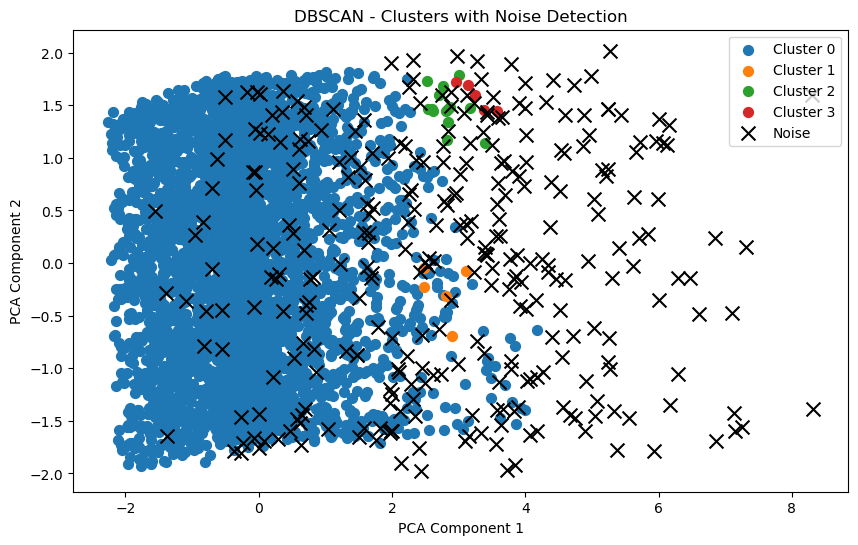

In [39]:
plt.figure(figsize=(10, 6))

labels = set(dbscan_v1.labels_)

for label in labels:
    if label == -1:
        color = 'k'
        marker = 'x'
        size = 100
        name = 'Noise'
    else:
        color = plt.cm.tab10(label)
        marker = 'o'
        size = 50
        name = f'Cluster {label}'
    
    points = pca_2d[dbscan_v1.labels_ == label]
    plt.scatter(points[:,0], points[:,1], c=[color], marker=marker, s=size, label=name)

plt.legend()
plt.title('DBSCAN - Clusters with Noise Detection')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

<a id="4.3"></a>

## <div style="text-align:center; border-radius:15px 50px; padding:7px; color:white; margin:0; font-size:100%; font-family:Pacifico; background-color:black; overflow:hidden"><b> Clustering Analysis Results</b></div>

Both clustering algorithms, K-Means and DBSCAN, were applied to segment customers based on Recency, Frequency, and Monetary Value (RFM) data. K-Means identified 5 distinct clusters, while DBSCAN highlighted customer groups based on data density. The analysis of results revealed valuable insights into customer behavior, enabling the creation of targeted marketing strategies for each identified segment.
The K-Means algorithm was chosen as it provided clearer and more interpretable customer segmentation, facilitating the definition of specific marketing strategies for each identified group.

In [3]:
print(rfm.groupby('Cluster').mean())

NameError: name 'rfm' is not defined

<table border="1" cellspacing="0" cellpadding="6">
  <thead>
    <tr>
      <th>Cluster</th>
      <th>Recência (R)</th>
      <th>Frequência (F)</th>
      <th>Monetário (M)</th>
      <th>Perfil do Cliente</th>
      <th>Descrição</th>
      <th>Estratégia Recomendada</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>0</td>
      <td>Média (~55 dias)</td>
      <td>Média (~45)</td>
      <td>Médio (~800)</td>
      <td>Clientes Ativos Moderados</td>
      <td>Clientes com frequência razoável e valor médio, mas sem compras muito recentes.</td>
      <td>Campanhas de incentivo para aumento de frequência e recência (ex: cupons e remarketing).</td>
    </tr>
    <tr>
      <td>1</td>
      <td>Alta (~264 dias)</td>
      <td>Baixa (~24)</td>
      <td>Baixo (~370)</td>
      <td>Clientes Inativos / Perdidos</td>
      <td>Clientes com longo tempo sem compra, baixa frequência e baixo valor monetário.</td>
      <td>Campanhas de reativação ou considerar como churn.</td>
    </tr>
    <tr>
      <td>2</td>
      <td>Baixa (~27 dias)</td>
      <td>Alta (~190)</td>
      <td>Muito Alto (~3048)</td>
      <td>Clientes Premium</td>
      <td>Clientes muito ativos, com alta frequência e alto valor gasto.</td>
      <td>Ofertas exclusivas, programas VIP e retenção prioritária.</td>
    </tr>
    <tr>
      <td>3</td>
      <td>Média (~52 dias)</td>
      <td>Média-Alta (~52)</td>
      <td>Médio (~768)</td>
      <td>Clientes Regulares</td>
      <td>Clientes com comportamento consistente, frequência razoável e valor moderado.</td>
      <td>Upsell e cross-sell para aumentar ticket médio.</td>
    </tr>
    <tr>
      <td>4</td>
      <td>Baixa (~18 dias)</td>
      <td>Muito Alta (~386)</td>
      <td>Muito Alto (~6927)</td>
      <td>Clientes VIP / Top Clientes</td>
      <td>Clientes extremamente engajados, com altíssima frequência e maior valor monetário.</td>
      <td>Atendimento personalizado, benefícios exclusivos e retenção máxima.</td>
    </tr>
  </tbody>
</table>

In [ ]:

rfm["CustomerID"] = rfm["CustomerID"].astype(int)


rfm = rfm.dropna()

df_retail = df_retail.dropna()

# Create df_rfm from rfm dataframe
df_rfm = rfm.copy()

# Save to CSV file
csv_path = 'dados/df_rfm.csv'
df_rfm.to_csv(csv_path, encoding='utf-8', index=False)


# Save to CSV file
csv_path = 'dados/DF_OnlineRetail.csv'
df_retail.to_csv(csv_path, encoding='utf-8', index=False)



print(f"✓ df_rfm criado com sucesso!")
print(f"✓ Arquivo salvo em: {csv_path}")
print(f"\nDimensões: {df_rfm.shape}")
print(f"\nPrimeiras linhas:\n{df_rfm.head()}")

<div style="font-family: Arial, sans-serif; line-height: 1.6;">

  <h2 style="color:#0a6ed1;">📊 Executive Dashboard Overview</h2>

  <p>
    To transform data into strategic decisions, we developed a set of analytics dashboards
    integrated with <b>SAP Analytics Cloud (SAC)</b>, focusing on intelligent customer segmentation.
  </p>

  <p>
    These dashboards consolidate complex customer behavior information into simple,
    intuitive, and action-oriented visualizations, enabling managers to have a clear and immediate business view.
  </p>

  <h3 style="color:#0854a0;">🔍 What You Will See Next</h3>

  <ul>
    <li>📈 <b>Consolidated customer view</b> with key performance indicators (KPIs)</li>
    <li>🧠 <b>Automatic AI-powered segmentation</b> using RFM and clustering algorithms</li>
    <li>💰 <b>Revenue analysis by customer profile</b></li>
    <li>⚠️ <b>Identification of at-risk customers (churn risk)</b></li>
    <li>🎯 <b>Foundation for targeted strategic actions</b></li>
  </ul>

  <h3 style="color:#0854a0;">🖥️ Customer Segmentation Dashboard</h3>

  <p>
    The image below presents the dashboard developed in SAC, where it is possible to explore customer segments,
    analyze purchase behavior, and identify business opportunities in a visual and interactive way.
  </p>

  <p style="color:gray; font-size: 13px;">
    (Inserir aqui a imagem do Dashboard SAC gerado)
  </p>

  <hr>

  <h3 style="color:#0854a0;">🔄 Arquitetura e Fluxo de Dados</h3>

  <p>
    Beyond visualization, the project was structured on a modern and scalable architecture,
    ensuring governance, performance, and integration with the SAP ecosystem.
  </p>

  <p>
    O fluxo de dados integra <b>Databricks</b>, <b>SAP Business Data Cloud</b> e <b>SAP Analytics Cloud</b>,
    enabling advanced processing, analytical modeling, and near-real-time consumption.
  </p>

  <p style="color:gray; font-size: 13px;">

     
  </p>

  <hr>

</div>

<div style="text-align:center;">
  <img src="images/DashBoard_RFM_PT.jpg" width="900">
  <p><i>Dashboard de Segmentação de Clientes RFM no SAP Analytics Cloud</i></p>
</div>

<div style="text-align:center;">
  <img src="images/DashBoard_RFM__LIST_PT.jpg" width="900">
  <p><i>Dashboard Lista de Clientes RFM no SAP Analytics Cloud</i></p>
</div>